# ResNet-18

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [2]:
use_mps = True
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('mps' if (use_mps and torch.backends.mps.is_available()) else 'cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('../data/splits/train.csv')

num_neg = (train_df['label'] == 0).sum()   # nevus
num_pos = (train_df['label'] == 1).sum()   # melanoma

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=True).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

Positive weight: tensor([0.1660], device='mps:0')


In [4]:
best_val_f2 = 0.0

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), '../models/resnet_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.1133, Acc: 0.8558, Recall: 0.0026, F2: 0.0032 | Val Loss: 0.1026, Acc: 0.8576, Recall: 0.0000, F2: 0.0000
Epoch [2/20] | Train Loss: 0.0885, Acc: 0.8576, Recall: 0.0013, F2: 0.0016 | Val Loss: 0.0894, Acc: 0.8645, Recall: 0.0479, F2: 0.0592
Saved best model at epoch 2
Epoch [3/20] | Train Loss: 0.0837, Acc: 0.8595, Recall: 0.0154, F2: 0.0192 | Val Loss: 0.0879, Acc: 0.8687, Recall: 0.0898, F2: 0.1095
Saved best model at epoch 3
Epoch [4/20] | Train Loss: 0.0810, Acc: 0.8639, Recall: 0.0462, F2: 0.0571 | Val Loss: 0.0853, Acc: 0.8713, Recall: 0.1078, F2: 0.1308
Saved best model at epoch 4
Epoch [5/20] | Train Loss: 0.0796, Acc: 0.8649, Recall: 0.0616, F2: 0.0757 | Val Loss: 0.0832, Acc: 0.8645, Recall: 0.0479, F2: 0.0592
Epoch [6/20] | Train Loss: 0.0808, Acc: 0.8657, Recall: 0.0616, F2: 0.0758 | Val Loss: 0.0833, Acc: 0.8704, Recall: 0.1078, F2: 0.1306
Epoch [7/20] | Train Loss: 0.0776, Acc: 0.8677, Recall: 0.0809, F2: 0.0988 | Val Loss: 0.0825, Acc: 0.8687

## Plot Loss and Accuracy Curves

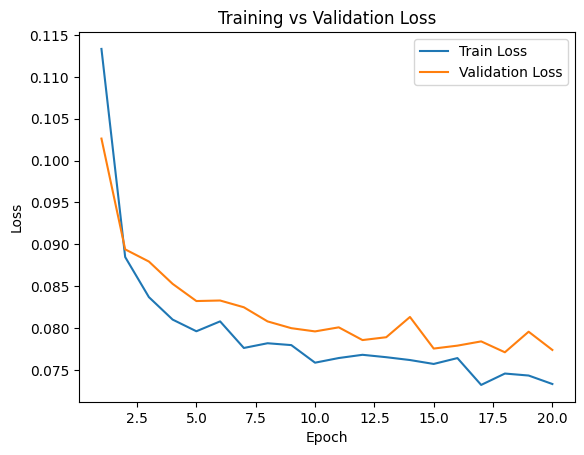

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

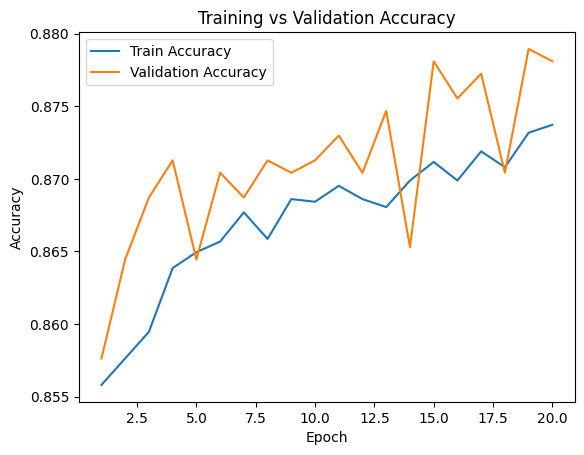

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

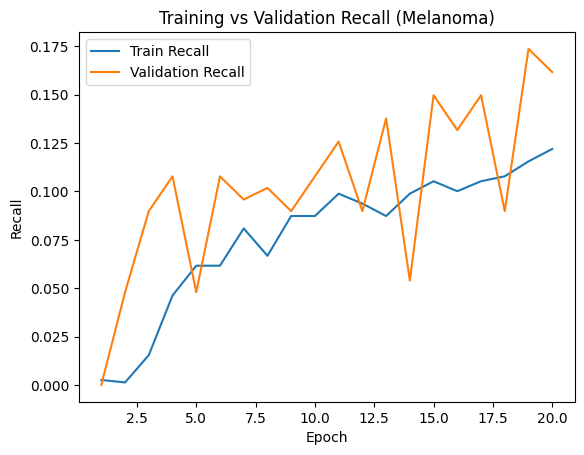

In [7]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

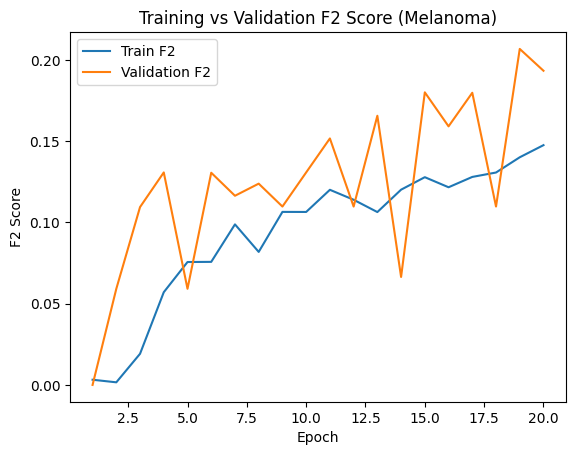

In [8]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load('../models/resnet_best.pth', map_location=device))
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= 0.1).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [10]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[1003    3]
 [ 143   24]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [11]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.8752    0.9970    0.9322      1006
           1     0.8889    0.1437    0.2474       167

    accuracy                         0.8755      1173
   macro avg     0.8821    0.5704    0.5898      1173
weighted avg     0.8772    0.8755    0.8347      1173



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()